In [12]:
import numpy as np
import matplotlib.pyplot as plt
import SADDlE
import time
import scipy
tau =1 
import timeit

In [13]:
def A3(N, t):
    main = t * np.ones(N)
    off  = -1 * np.ones(N - 1)
    return scipy.sparse.diags([off, main, off], offsets=[-1, 0, 1], format="csr")

In [14]:
np.set_printoptions(precision=4, suppress=True, linewidth=100000)
N = 2
print(f"N={N}")
T = scipy.sparse.diags([np.ones(N-1), np.ones(N), np.ones(N-1)], offsets=[-1, 0, 1], format="csr")


A0 = (3/tau)*(scipy.sparse.eye(N) - T)
A1 = (1/tau)*(scipy.sparse.eye(N) - T)

dde = SADDlE.generalDDE(N, [tau], [tau], [0], A0, [A1], [lambda t, n = N: A3(n, t)], None, True)
dde = dde.convertToTheoreticalDDE()

Am = SADDlE.assembleAm(dde, M=5, useSparse=True)
print(Am.toarray())
    

N=2
[[  0.      -3.02    -0.0172  -0.1804  -0.1035  -0.2996  -0.1961  -0.2996  -0.1631  -0.1804  -0.02    -1.02  ]
 [ -3.02     0.      -0.1804  -0.0172  -0.2996  -0.1035  -0.2996  -0.1961  -0.1804  -0.1631  -1.02    -0.02  ]
 [  5.2361   0.      -2.3416   0.      -4.       0.       1.7889   0.      -1.2361   0.       0.5528   0.    ]
 [  0.       5.2361   0.      -2.3416   0.      -4.       0.       1.7889   0.      -1.2361   0.       0.5528]
 [ -1.4472   0.       4.       0.      -0.3416   0.      -3.2361   0.       1.7889   0.      -0.7639   0.    ]
 [  0.      -1.4472   0.       4.       0.      -0.3416   0.      -3.2361   0.       1.7889   0.      -0.7639]
 [  0.7639   0.      -1.7889   0.       3.2361   0.       0.3416   0.      -4.       0.       1.4472   0.    ]
 [  0.       0.7639   0.      -1.7889   0.       3.2361   0.       0.3416   0.      -4.       0.       1.4472]
 [ -0.5528   0.       1.2361   0.      -1.7889   0.       4.       0.       2.3416   0.      -5.2361   0.   

In [15]:
print(T.toarray())

[[1. 1.]
 [1. 1.]]


In [16]:
durations = []
    
for N in  np.logspace(2, 5, 5, dtype=int):
    print(f"N={N}")
    main_diag = np.zeros(N)
    main_diag[0] = main_diag[-1] = 1
    T = scipy.sparse.diags([np.ones(N-1), np.zeros(N), main_diag], offsets=[-1, 0, 1], format="csr")

    A0 = (3/tau)*(scipy.sparse.eye(N) - T)
    A1 = (1/tau)*(scipy.sparse.eye(N) - T)

    dde = SADDlE.generalDDE(N, [tau], [tau], [0], A0, [A1], [lambda t, n = N: A3(n, t)], None, True)
    dde = dde.convertToTheoreticalDDE()
    
    time = sum(timeit.repeat("SADDlE.assembleAm(dde, M=50, useSparse=True)", globals=globals(), number=15, repeat=2))/30
    
    
    durations.append(time)
    print(f"Time: {time:.4f} seconds")

N=100
Time: 0.0082 seconds
N=562
Time: 0.0277 seconds
N=3162
Time: 0.1101 seconds
N=17782
Time: 0.5799 seconds
N=100000
Time: 3.4102 seconds


In [17]:
def A3dense(N, t):
    main = t * np.ones(N)
    off  = -1 * np.ones(N - 1)
    return np.diag(main) + np.diag(off, k=-1) + np.diag(off, k=1)

In [18]:
durations_dense = []
    
for N in  np.logspace(2, 2.8, 7, dtype=int):
    print(f"N={N}")
    T = np.diag([1.0]*(N-1), k=-1) + np.zeros(N) + np.diag([1.0]*(N-1), k=1)
    T[0, 0] = T[-1, -1] = 1

    A0 = (3/tau)*(np.eye(N) - T)
    A1 = (1/tau)*(np.eye(N) - T)

    dde = SADDlE.generalDDE(N, [tau], [tau], [0], A0, [A1], [lambda t, n = N: A3(n, t)], None, False)
    dde = dde.convertToTheoreticalDDE()
    
    time = sum(timeit.repeat("SADDlE.assembleAm(dde, M=50, useSparse=False)", globals=globals(), number=15, repeat=2))/30
    
    
    durations_dense.append(time)
    print(f"Time: {time:.4f} seconds")

N=100
Time: 0.0662 seconds
N=135
Time: 0.1213 seconds
N=184
Time: 0.2117 seconds
N=251
Time: 0.3777 seconds
N=341
Time: 0.7025 seconds
N=464
Time: 1.2870 seconds
N=630
Time: 2.3940 seconds


In [29]:
data = np.loadtxt('/home/jan/projects/SADDlE/tests/runtime_results.csv', delimiter=',')

# Extract columns into separate arrays
n_values = data[:, 0]
runtimes = data[:, 1]

data = np.loadtxt('/home/jan/projects/SADDlE/tests/runtime_results_multi.csv', delimiter=',')

n_values_multi = data[:, 0]
runtimes_multi = data[:, 1]

[    10    100   1000  10000 100000]


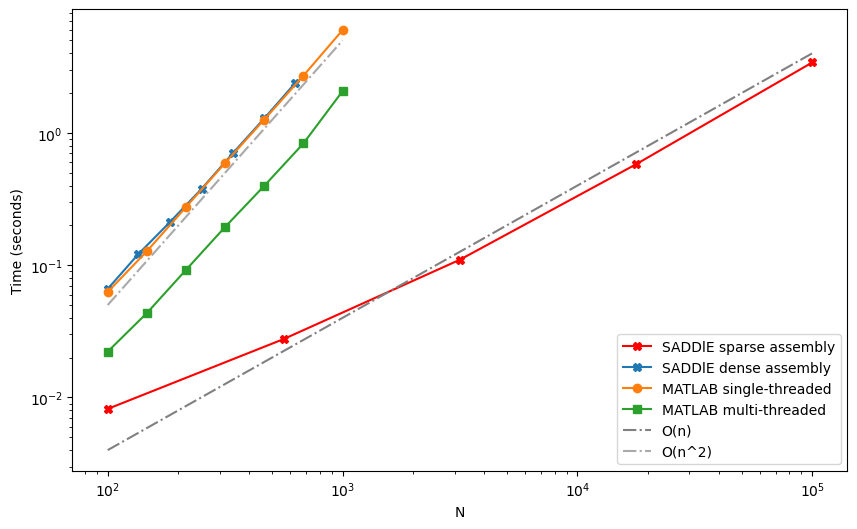

In [ ]:
import tikzplotlib
fig, (ax1) = plt.subplots(figsize=(10, 6))
ax1.plot(np.logspace(2, 5, 5, dtype=int), durations, '-X', label="SADDlE sparse assembly", color="red")
ax1.plot(np.logspace(2, 2.8, 7, dtype=int), durations_dense, '-X', label="SADDlE dense assembly")
ax1.plot(n_values, runtimes, '-o', label="MATLAB single-threaded")
ax1.plot(n_values_multi, runtimes_multi, '-s', label="MATLAB multi-threaded")
space = np.logspace(1, 5, 5, dtype=int)
print(space)
ax1.plot(space[1:], 0.00004*space[1:], '-.', label="O(n)", color="gray")
ax1.plot(space[1:3], 0.000005*space[1:3]**2, '-.', label="O(n^2)", color="darkgray")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("N")
ax1.set_ylabel("Time (seconds)")
ax1.legend()
tikzplotlib.save("test.tex")